In [33]:
import pandas as pd
import numpy as np
import os
import seaborn as sns

import matplotlib.gridspec as gridspec

from scipy.stats import pearsonr, spearmanr
from scipy.stats import rankdata
from matplotlib import pyplot as plt
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve, auc

from sklearn.neural_network import MLPRegressor, MLPClassifier



In [6]:
def get_one_hot_encoding(df, df_name):

    all_columns = {
    "nmt": ["Y20", "F253"],
    "gfp": ["L42", "V224"],
    "lov": ["G2", "T112"],
    "pard3": ["L48","R82"],
    "gcn4": ["S101","S144"],
    "pte": ["I72", "M283"],
    "aamyl": ["P4", "D425"],
    "trpb": ["A104", "Y301"],
    "his": ["L7", "D211"],
    "casp": ["D561", "R588"]
    }

    columns_for_ohe = df.columns
    si = np.where(columns_for_ohe == all_columns[df_name][0])[0][0]
    ei = np.where(columns_for_ohe == all_columns[df_name][1])[0][0]+1
    
    one_hot_encoding = pd.get_dummies(df[columns_for_ohe[si:ei]])

    return one_hot_encoding



In [ ]:

dataset = pd.read_csv('/home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/pte/pte.csv')

Index(['I72', 'F98', 'H220', 'H223', 'L237', 'L269', 'F272', 'M283',
       'num_muts', 'full_seq', 'inactive', 'pad_regions', 'serial_number',
       'activity', 'design', 'design_2', 'malathion', 'p-nitrophenyl_acetate',
       'p-nitrophenyl_octanoate', 'naphthyl_acetate', 'nonanoic_lactone',
       'paraoxon', 'EMP', 'IMP', 'CMP', 'TBBL', 'PMP'],
      dtype='object')


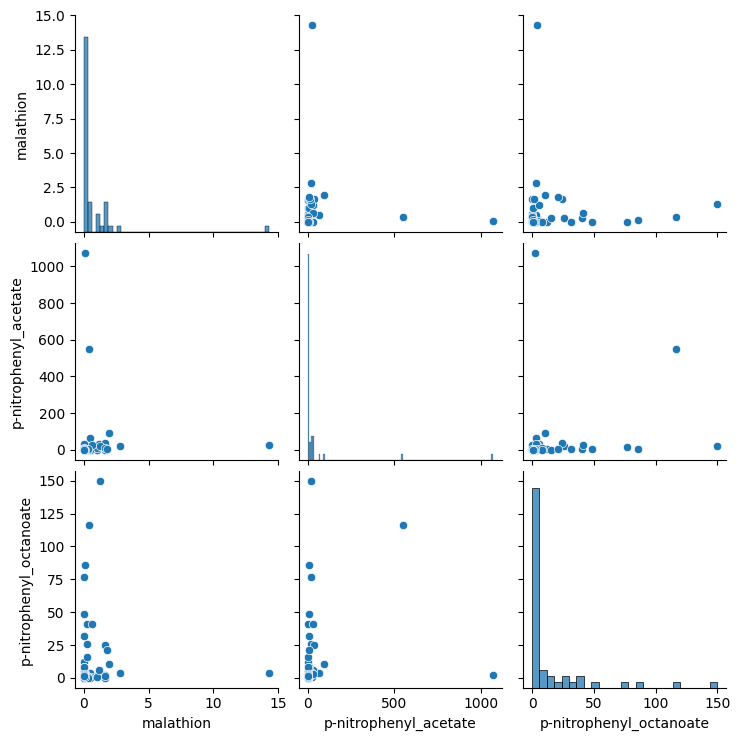

In [32]:
print(dataset.columns)
dataset.head()



sns.pairplot(dataset[["malathion", "p-nitrophenyl_acetate", "p-nitrophenyl_octanoate"]])


In [49]:
ohe = get_one_hot_encoding(dataset, "pte")

print(dataset.shape)
print(ohe.shape)
ohe.head()


activity = dataset["malathion"].to_numpy()
ohe = ohe.to_numpy()

(50, 27)
(50, 22)


/home/labs/fleishman/itayta/.conda/envs/esm_env/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: UserWarning: Got `batch_size` less than 1 or larger than sample size. It is going to be clipped
  warnings.warn(
/home/labs/fleishman/itayta/.conda/envs/esm_env/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/labs/fleishman/itayta/.conda/envs/esm_env/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: UserWarning: Got `batch_size` less than 1 or larger than sample size. It is going to be clipped
  warnings.warn(
/home/labs/fleishman/itayta/.conda/envs/esm_env/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.

Iteration 1: Spearman correlation = 0.6639, p-value = 6.345e-05
Iteration 2: Spearman correlation = 0.6909, p-value = 2.372e-05
Iteration 3: Spearman correlation = 0.5518, p-value = 0.001571
Iteration 4: Spearman correlation = 0.5447, p-value = 0.001857
Iteration 5: Spearman correlation = 0.6334, p-value = 0.000172
Iteration 6: Spearman correlation = 0.6447, p-value = 0.0001203
Iteration 7: Spearman correlation = 0.6607, p-value = 7.082e-05
Iteration 8: Spearman correlation = 0.5325, p-value = 0.002454
Iteration 9: Spearman correlation = 0.5827, p-value = 0.0007281
Iteration 10: Spearman correlation = 0.6003, p-value = 0.0004527
Iteration 11: Spearman correlation = 0.7045, p-value = 1.389e-05
Iteration 12: Spearman correlation = 0.6629, p-value = 6.57e-05
Iteration 13: Spearman correlation = 0.6559, p-value = 8.32e-05
Iteration 14: Spearman correlation = 0.7458, p-value = 2.244e-06
Iteration 15: Spearman correlation = 0.6635, p-value = 6.426e-05
Iteration 16: Spearman correlation = 0.5

/home/labs/fleishman/itayta/.conda/envs/esm_env/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/labs/fleishman/itayta/.conda/envs/esm_env/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: UserWarning: Got `batch_size` less than 1 or larger than sample size. It is going to be clipped
  warnings.warn(
/home/labs/fleishman/itayta/.conda/envs/esm_env/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/labs/fleishman/itayta/.conda/envs/esm_env/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: UserWarning: Got `batch_size` less than 1 or larger than sample size. It is going to be clipped

Iteration 57: Spearman correlation = 0.6922, p-value = 2.26e-05
Iteration 58: Spearman correlation = 0.6141, p-value = 0.0003064
Iteration 59: Spearman correlation = 0.4975, p-value = 0.005153
Iteration 60: Spearman correlation = 0.7540, p-value = 1.502e-06
Iteration 61: Spearman correlation = 0.5266, p-value = 0.002793
Iteration 62: Spearman correlation = 0.6899, p-value = 2.465e-05
Iteration 63: Spearman correlation = 0.4945, p-value = 0.00547
Iteration 64: Spearman correlation = 0.4826, p-value = 0.006916
Iteration 65: Spearman correlation = 0.5731, p-value = 0.000931
Iteration 66: Spearman correlation = 0.4720, p-value = 0.008455
Iteration 67: Spearman correlation = 0.5768, p-value = 0.000849
Iteration 68: Spearman correlation = 0.4739, p-value = 0.008163
Iteration 69: Spearman correlation = 0.6082, p-value = 0.0003635
Iteration 70: Spearman correlation = 0.6131, p-value = 0.0003158
Iteration 71: Spearman correlation = 0.7004, p-value = 1.637e-05
Iteration 72: Spearman correlation 

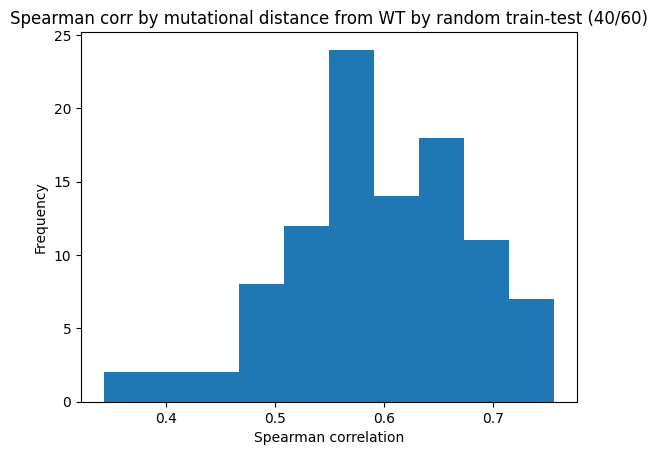

In [65]:
mlp_base_parameters = {
    "activation": 'relu',
    "solver": "adam", # try to iterate between "adamw" / "lbfgs"
    "batch_size": 128,
    "alpha": 0.5,
    "learning_rate_init": 1e-3,
    "max_iter": 20,
    "random_state": 4321,
    "n_iter_no_change": 10,
    "verbose": False
}


# random train test

N_S, F = ohe.shape 
train_size = 20
iterations = 100
results = []

all_indices = np.arange(0, N_S)


for i in range(iterations):
    train_indices = np.random.choice(all_indices, size=train_size, replace=False)
    test_indices = np.setdiff1d(all_indices, train_indices)

    X_train = ohe[train_indices]
    y_train = activity[train_indices]
    X_test = ohe[test_indices]
    y_test = activity[test_indices]



    mlp_ohe = MLPRegressor(hidden_layer_sizes=(50), **mlp_base_parameters)
    mlp_ohe.fit(X_train, y_train.astype(float))
    y_pred = mlp_ohe.predict(X_test)

    corr, pval = spearmanr(y_pred, y_test)
    print(f"Iteration {i+1}: Spearman correlation = {corr:.4f}, p-value = {pval:.4g}")
    results.append(corr)

plt.hist(np.array(results))
plt.xlabel("Spearman correlation")
plt.ylabel("Frequency")
plt.title("Spearman corr by mutational distance from WT by random train-test (40/60)")
plt.show()


In [58]:
mlp_base_parameters = {
    "activation": 'relu',
    "solver": "adam", # try to iterate between "adamw" / "lbfgs"
    "batch_size": 128,
    "alpha": 0.5,
    "learning_rate_init": 1e-3,
    "max_iter": 20,
    "random_state": 4321,
    "n_iter_no_change": 10,
    "verbose": False
}


# random train test

N_S, F = ohe.shape 
train_size = 20
iterations = 100
results = []

all_indices = np.arange(0, N_S)

for nm in range(3, 6):
    train_indices = np.where(dataset["num_muts"] == nm)[0] # Can also be train on <= nm
    test_indices = np.where(dataset["num_muts"] != nm)[0] 

    X_train = ohe[train_indices]
    y_train = activity[train_indices]
    X_test = ohe[test_indices]
    y_test = activity[test_indices]



    mlp_ohe = MLPRegressor(hidden_layer_sizes=(50), **mlp_base_parameters)
    mlp_ohe.fit(X_train, y_train.astype(float))
    y_pred = mlp_ohe.predict(X_test)

    corr, pval = spearmanr(y_pred, y_test)
    print(f"Nm in train: {nm}, Spearman correlation = {corr:.4f}, p-value = {pval:.4g}")
    results.append({"n_muts": nm, "corr": corr})



Nm in train: 3, Spearman correlation = 0.5668, p-value = 0.0003133
Nm in train: 4, Spearman correlation = 0.6336, p-value = 0.0001299
Nm in train: 5, Spearman correlation = 0.6049, p-value = 0.0001512


/home/labs/fleishman/itayta/.conda/envs/esm_env/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: UserWarning: Got `batch_size` less than 1 or larger than sample size. It is going to be clipped
  warnings.warn(
/home/labs/fleishman/itayta/.conda/envs/esm_env/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/labs/fleishman/itayta/.conda/envs/esm_env/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: UserWarning: Got `batch_size` less than 1 or larger than sample size. It is going to be clipped
  warnings.warn(
/home/labs/fleishman/itayta/.conda/envs/esm_env/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.

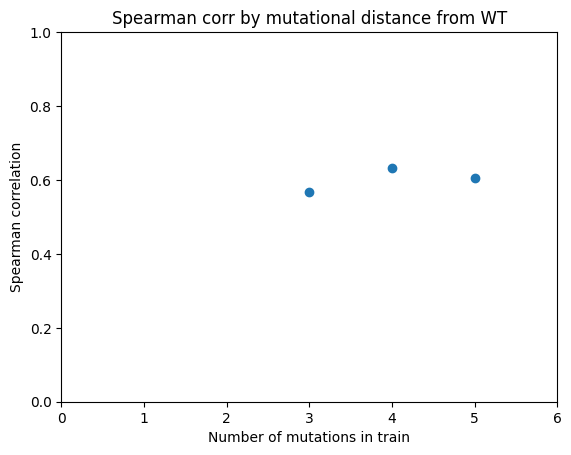

In [63]:
results = pd.DataFrame(results)
plt.scatter(results["n_muts"], results["corr"])
plt.xlabel("Number of mutations in train")
plt.ylabel("Spearman correlation")
plt.xlim(0, 6),
plt.ylim(0, 1)
plt.title("Spearman corr by mutational distance from WT")
plt.show()